# Modelación de variables contaminantes con Ecuaciones Diferenciales Estocásticas 

In [1]:
import os
from pathlib import Path
print("Directorio actual:", os.getcwd())

current_dir = Path.cwd()
project_root = current_dir
while not (project_root / '.git').exists() and project_root != project_root.parent:
    project_root = project_root.parent
    os.chdir("..")

print(f"Raíz del proyecto: {project_root}")
print("CWD cambiado a raíz del proyecto")

Directorio actual: /home/ferrus/Documents/university/semester_x/MA2003B/PROYECTO_MA2003B/notebooks/03_models
Raíz del proyecto: /home/ferrus/Documents/university/semester_x/MA2003B/PROYECTO_MA2003B
CWD cambiado a raíz del proyecto


## Visualización de linea de tiempo

In [2]:
import pandas as pd
import numpy as np

path_master_df = "data/processed/master_table.csv"
df_master = pd.read_csv(path_master_df, low_memory=False)

path_tabla_co_sureste = "data/interim/tabla_anual_co_sureste.csv"
df_co_sureste = pd.read_csv(path_tabla_co_sureste)

df_co_sureste.head()

,hour_of_year,co_2022,co_2023,co_2024
0,1,NaN,3.67,4.21
1,2,3.28,3.90,4.21
2,3,3.25,4.28,4.37
3,4,3.02,3.15,3.35
4,5,2.73,2.32,3.53


### Sub rutinas útiles

Testing with sample data...
   hour_of_year  co_2022  co_2023  co_2024
0             1      NaN     3.67     4.21
1             2     3.28     3.90     4.21
2             3     3.25     4.28     4.37
3             4     3.02     3.15     3.35
4             5     2.73     2.32     3.53

=== Overlapping Plot ===


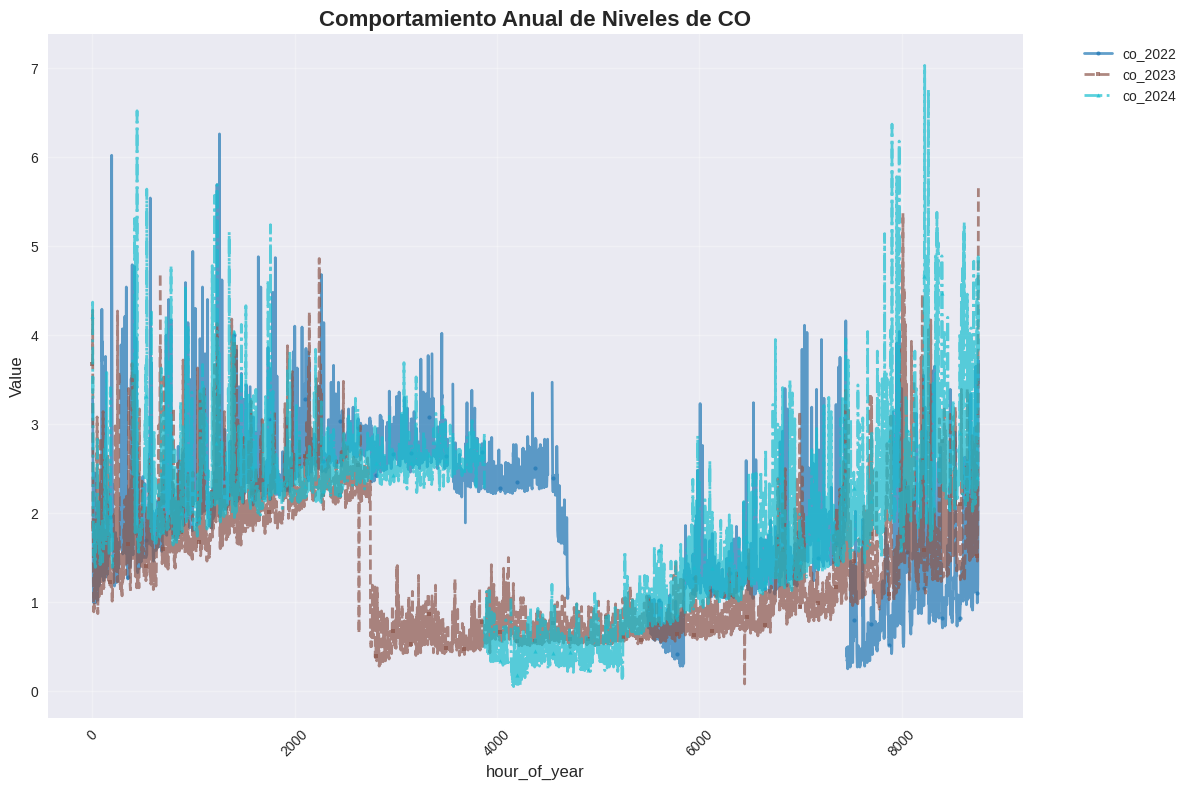


=== Separate Plots ===


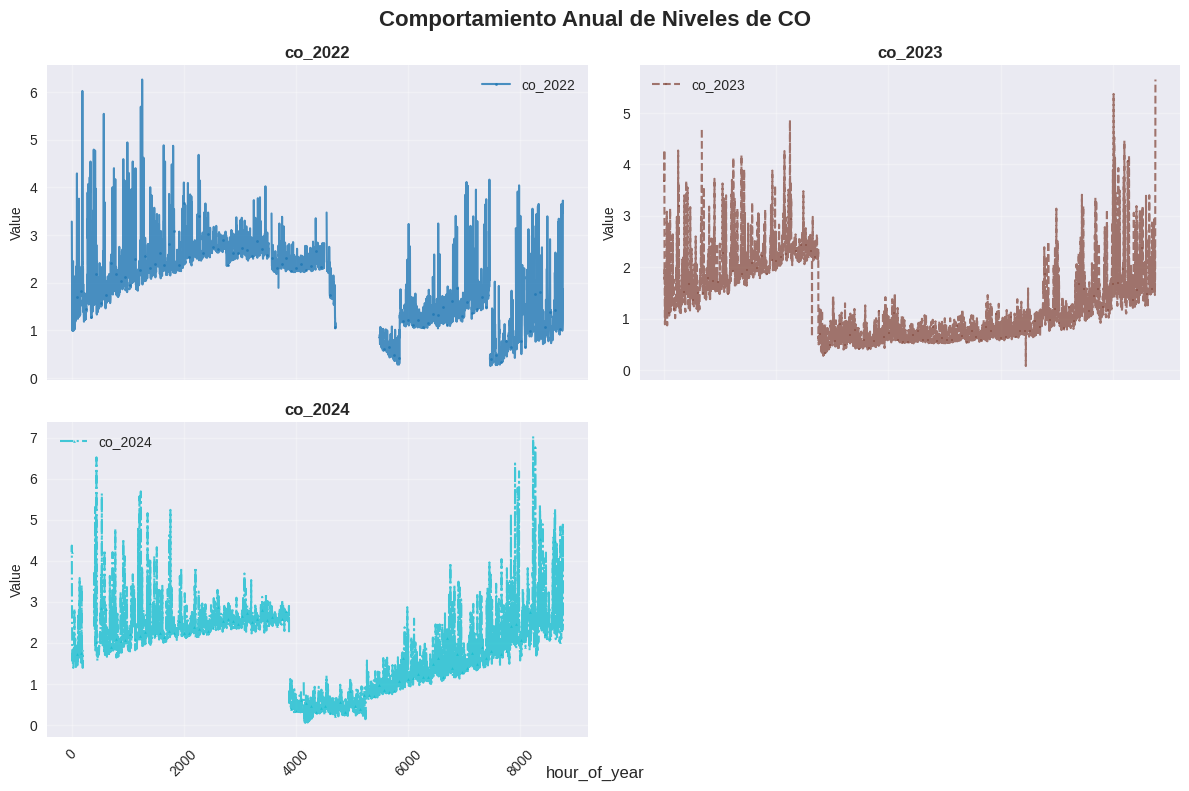

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional, List, Union
import seaborn as sns

def _prepare_timeseries_data(df: pd.DataFrame, index_col: str) -> tuple[pd.DataFrame, List[str], np.ndarray, List[str], List[str]]:
    """
    Prepare data and styling elements for time series visualization
    
    Args:
        df: DataFrame with time series data
        index_col: Name of the index/time column (can be datetime or numeric)
    
    Returns:
        Tuple of (prepared_df, value_columns, colors, linestyles, markers)
    """
    df_plot = df.copy()
    
    # Check if index is numeric (hour of year) or datetime-like
    if pd.api.types.is_numeric_dtype(df_plot[index_col]):
        # Keep as numeric index for hour-of-year data
        df_plot = df_plot.set_index(index_col)
    else:
        # Try to convert to datetime
        try:
            df_plot[index_col] = pd.to_datetime(df_plot[index_col])
            df_plot = df_plot.set_index(index_col)
        except (ValueError, TypeError):
            # If conversion fails, keep as is but set as index
            df_plot = df_plot.set_index(index_col)
    
    value_cols = [col for col in df_plot.columns]
    n_series = len(value_cols)
    
    if n_series == 0:
        raise ValueError("No value columns found in DataFrame")
    
    colors = plt.cm.tab10(np.linspace(0, 1, n_series)) # type: ignore
    linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
    markers = ['o', 's', '^', 'v', 'D', 'x', '+', '*']
    
    return df_plot, value_cols, colors, linestyles, markers


def _create_overlapping_plot(df_plot: pd.DataFrame, value_cols: List[str], colors: np.ndarray, 
                           linestyles: List[str], markers: List[str], figsize: tuple, 
                           title: Optional[str], index_col: str) -> plt.Figure: # type: ignore
    """
    Create overlapping time series plot
    
    Args:
        df_plot: Prepared DataFrame with datetime index
        value_cols: List of column names to plot
        colors: Array of colors for series
        linestyles: List of line styles
        markers: List of marker styles
        figsize: Figure size
        title: Plot title
        index_col: Name of original index column for labeling
    
    Returns:
        matplotlib Figure object
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, col in enumerate(value_cols):
        ax.plot(df_plot.index, df_plot[col],
               color=colors[i % len(colors)],
               linestyle=linestyles[i % len(linestyles)],
               marker=markers[i % len(markers)],
               markersize=3,
               markevery=max(1, len(df_plot) // 50),
               linewidth=2,
               alpha=0.7,
               label=col)
    
    ax.set_xlabel(f'{index_col}', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)
    
    if title:
        ax.set_title(title, fontsize=16, fontweight='bold')
    
    return fig

def _create_separate_plots(df_plot: pd.DataFrame, value_cols: List[str], colors: np.ndarray,
                         linestyles: List[str], markers: List[str], figsize: tuple,
                         title: Optional[str], index_col: str) -> plt.Figure: # type: ignore
    """
    Create separate subplot for each time series
    
    Args:
        df_plot: Prepared DataFrame with datetime index
        value_cols: List of column names to plot
        colors: Array of colors for series
        linestyles: List of line styles
        markers: List of marker styles
        figsize: Figure size
        title: Main title
        index_col: Name of original index column for labeling
    
    Returns:
        matplotlib Figure object
    """
    n_series = len(value_cols)
    n_rows = int(np.ceil(n_series / 2)) if n_series > 1 else 1
    n_cols = 2 if n_series > 1 else 1
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True)
    if n_series == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(value_cols):
        ax = axes[i]
        
        ax.plot(df_plot.index, df_plot[col], 
               color=colors[i % len(colors)],
               linestyle=linestyles[i % len(linestyles)],
               marker=markers[i % len(markers)],
               markersize=2,
               markevery=max(1, len(df_plot) // 100),
               linewidth=1.5,
               alpha=0.8,
               label=col)
        
        ax.set_title(f'{col}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Value', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for i in range(n_series, len(axes)):
        axes[i].set_visible(False)
    
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    
    fig.text(0.5, 0.02, f'{index_col}', ha='center', fontsize=12)
    
    return fig

def visualize_ts_dataframe(df: pd.DataFrame, 
                        index_col: str,
                        separate_plots: bool = False,
                        figsize: tuple = (12, 8),
                        title: Optional[str] = None,
                        style: str = 'seaborn-v0_8') -> plt.Figure: # type: ignore
    """
    Visualize time series data with options for overlapping or separate plots
    
    Args:
        df: DataFrame with time series data
        index_col: Name of the index/time column
        separate_plots: If True, create separate subplot for each series
        figsize: Figure size as (width, height)
        title: Main title for the plot(s)
        style: Matplotlib style to use
    
    Returns:
        matplotlib Figure object
    """
    plt.style.use(style)
    
    df_plot, value_cols, colors, linestyles, markers = _prepare_timeseries_data(df, index_col)
    
    if separate_plots:
        fig = _create_separate_plots(df_plot, value_cols, colors, linestyles, markers, 
                                   figsize, title, index_col)
    else:
        fig = _create_overlapping_plot(df_plot, value_cols, colors, linestyles, markers,
                                     figsize, title, index_col)
    
    plt.tight_layout()
    return fig

def interactive_timeseries_visualizer(df: pd.DataFrame, index_col: str) -> None:
    """
    Interactive wrapper that asks user preferences and visualizes accordingly
    
    Args:
        df: DataFrame with time series data
        index_col: Name of the index/time column
    """
    # Get basic info about the data
    value_cols = [col for col in df.columns if col != index_col]
    n_series = len(value_cols)
    
    print(f"Found {n_series} time series columns: {value_cols}")
    print(f"Time range: {df[index_col].min()} to {df[index_col].max()}")
    print(f"Total data points: {len(df)}")
    
    # Ask user preferences
    separate = input("\nWould you like separate plots for each time series? (y/n): ").lower().strip()
    separate_plots = separate in ['y', 'yes', 'true', '1']
    
    # Optional customizations
    custom_title = input("Enter a title for the plot (or press Enter for default): ").strip()
    title = custom_title if custom_title else f"Time Series Visualization - {', '.join(value_cols)}"
    
    # Create visualization
    fig = visualize_ts_dataframe(
        df=df,
        index_col=index_col,
        separate_plots=separate_plots,
        title=title
    )
    
    plt.show()
    
    return fig # type: ignore

# Quick test function
def quick_visualizer():
    """Test the visualizer with sample data"""
    # Create sample data
    
    print("Testing with sample data...")
    print(df_co_sureste.head())
    
    # Test both visualization modes
    print("\n=== Overlapping Plot ===")
    fig1 = visualize_ts_dataframe(df_co_sureste, 'hour_of_year', separate_plots=False, 
                               title="Comportamiento Anual de Niveles de CO")
    plt.show()
    
    print("\n=== Separate Plots ===")
    fig2 = visualize_ts_dataframe(df_co_sureste, 'hour_of_year', separate_plots=True,
                               title="Comportamiento Anual de Niveles de CO")
    plt.show()


quick_visualizer()

## Regularización de la tabla (tratamiento de N.A)

In [4]:
from src.data_prep import imputation

imputer = imputation.TimeSeriesImputer(df_co_sureste)
# Aplicar todas las estrategias a una columna específica
df_co_2022_imputed = imputer.bootstrap_imputation_df('co_2022')


In [5]:
df_co_2022_imputed

,hour_of_year,co_2022
0,1,1.68651
1,2,3.28000
2,3,3.25000
3,4,3.02000
4,5,2.73000
...,...,...
8755,8756,1.65000
8756,8757,2.04000
8757,8758,3.02000
8758,8759,3.72000


## Suavizamiento de los datos

In [6]:
def smooth_to_six_hour_windows(df: pd.DataFrame, 
                              index_col: str, 
                              value_col: str,
                              method: str = 'mean') -> pd.DataFrame:
    """
    Smooth hourly time series data to 6-hour windows
    
    Args:
        df: DataFrame with time series data
        index_col: Name of the index column (hour_of_year or datetime)
        value_col: Name of the value column to smooth
        method: Aggregation method ('mean', 'median', 'max', 'min')
    
    Returns:
        DataFrame with smoothed data (4 values per day instead of 24)
    """
    df_work = df.copy()
    
    # Ensure index is numeric for grouping
    if not pd.api.types.is_numeric_dtype(df_work[index_col]):
        raise ValueError(f"Index column '{index_col}' must be numeric (hour_of_year)")
    
    # Create 6-hour window groups
    # Hour 1-6 -> Window 0, Hour 7-12 -> Window 1, etc.
    df_work['window_group'] = ((df_work[index_col] - 1) // 6).astype(int)
    
    # Calculate window start hour for new index
    df_work['window_start'] = df_work['window_group'] * 6 + 1
    
    # Remove rows with NaN values before aggregation
    df_clean = df_work.dropna(subset=[value_col])
    
    # Group by window and aggregate
    agg_methods = {
        'mean': 'mean',
        'median': 'median', 
        'max': 'max',
        'min': 'min'
    }
    
    if method not in agg_methods:
        raise ValueError(f"Method must be one of: {list(agg_methods.keys())}")
    
    result = df_clean.groupby('window_start').agg({
        value_col: agg_methods[method],
        'window_group': 'first'  # Keep for reference
    }).reset_index()
    
    # Create sequential index starting from 1
    result[index_col] = range(1, len(result) + 1)
    
    # Clean up result
    result = result.rename(columns={
        value_col: f'{value_col}_{method}_6h'
    })
    
    result = result[[index_col, f'{value_col}_{method}_6h']]
    
    return result


def smooth_multiple_series(df: pd.DataFrame,
                          index_col: str,
                          method: str = 'mean') -> pd.DataFrame:
    """
    Smooth multiple time series columns to 6-hour windows
    
    Args:
        df: DataFrame with multiple time series columns
        index_col: Name of the index column
        method: Aggregation method
    
    Returns:
        DataFrame with all series smoothed
    """
    value_cols = [col for col in df.columns if col != index_col]
    
    if not value_cols:
        raise ValueError("No value columns found")
    
    # Process first column to establish index
    result = smooth_to_six_hour_windows(df, index_col, value_cols[0], method)
    
    # Process remaining columns and merge
    for col in value_cols[1:]:
        col_smoothed = smooth_to_six_hour_windows(df, index_col, col, method)
        result = result.merge(col_smoothed, on=index_col, how='outer')
    
    return result



def analyze_smoothing_effect(original_df: pd.DataFrame,
                           smoothed_df: pd.DataFrame, 
                           index_col: str,
                           value_col: str) -> dict:
    """
    Analyze the effect of smoothing on data characteristics
    
    Args:
        original_df: Original hourly data
        smoothed_df: Smoothed 6-hour data
        index_col: Name of index column
        value_col: Name of value column (use base name without suffix)
    
    Returns:
        Dictionary with smoothing statistics
    """
    # Find smoothed column name
    smoothed_col = None
    for col in smoothed_df.columns:
        if col.startswith(value_col) and col != index_col:
            smoothed_col = col
            break
    
    if smoothed_col is None:
        raise ValueError(f"Could not find smoothed column for {value_col}")
    
    original_values = original_df[value_col].dropna()
    smoothed_values = smoothed_df[smoothed_col].dropna()
    
    stats = {
        'original_points': len(original_values),
        'smoothed_points': len(smoothed_values),
        'compression_ratio': len(original_values) / len(smoothed_values),
        'original_std': original_values.std(),
        'smoothed_std': smoothed_values.std(),
        'noise_reduction': 1 - (smoothed_values.std() / original_values.std()),
        'original_range': original_values.max() - original_values.min(),
        'smoothed_range': smoothed_values.max() - smoothed_values.min()
    }
    
    return stats

# Example usage and demonstration
def quick_smoothing(sample_df: pd.DataFrame, column: str):
    """Demonstrate the smoothing functionality"""
    
    # Apply smoothing
    smoothed_df = smooth_to_six_hour_windows(sample_df, 'hour_of_year', column, 'max')
    
    # Analyze effect
    stats = analyze_smoothing_effect(sample_df, smoothed_df, 'hour_of_year', column)
    
    print("Smoothing Analysis:")
    print(f"Data points: {stats['original_points']} → {stats['smoothed_points']}")
    print(f"Compression ratio: {stats['compression_ratio']:.1f}:1")
    print(f"Standard deviation: {stats['original_std']:.3f} → {stats['smoothed_std']:.3f}")
    print(f"Noise reduction: {stats['noise_reduction']:.1%}")
    print(f"Range: {stats['original_range']:.2f} → {stats['smoothed_range']:.2f}")
    
    return sample_df, smoothed_df, stats


original, df_co_2022_smoothed, analysis = quick_smoothing(df_co_2022_imputed, "co_2022")

Smoothing Analysis:
Data points: 8760 → 1460
Compression ratio: 6.0:1
Standard deviation: 0.743 → 0.843
Noise reduction: -13.4%
Range: 6.01 → 5.95


In [7]:
df_co_2022_smoothed.head()

,hour_of_year,co_2022_max_6h
0,1,3.28
1,2,1.98
2,3,1.04
3,4,2.38
4,5,2.45


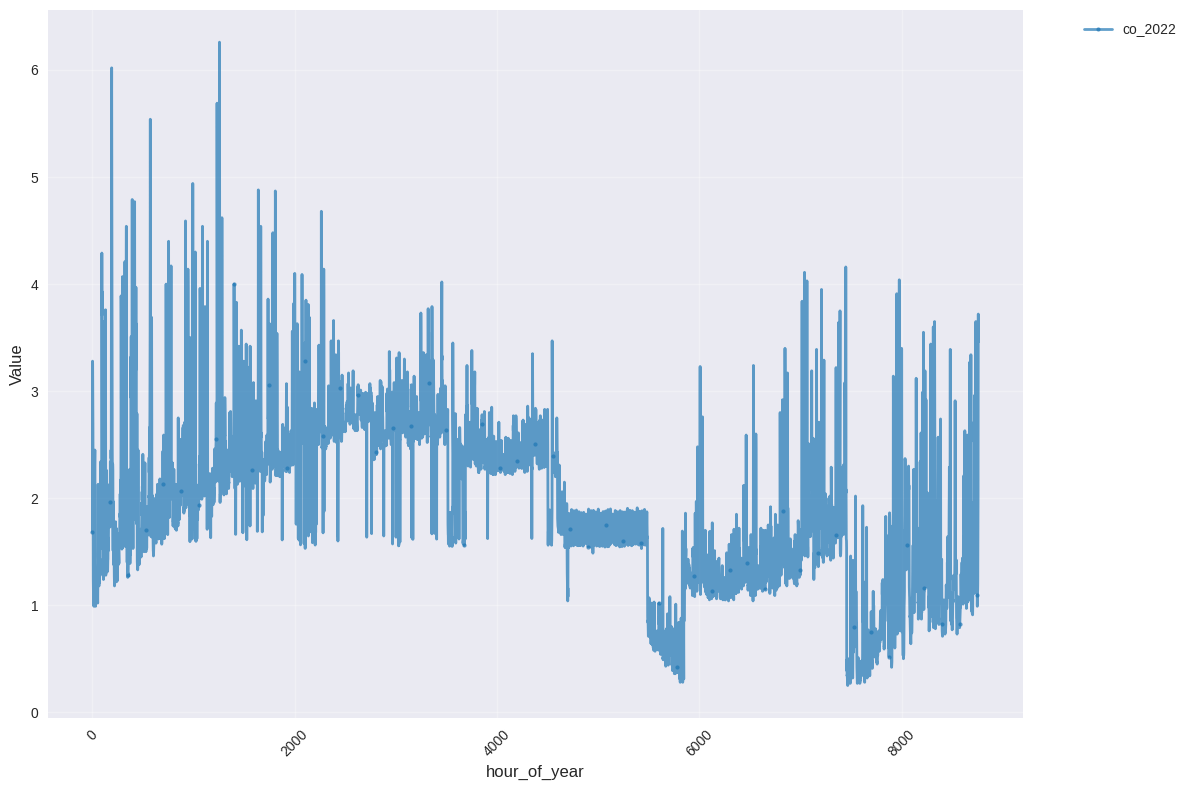

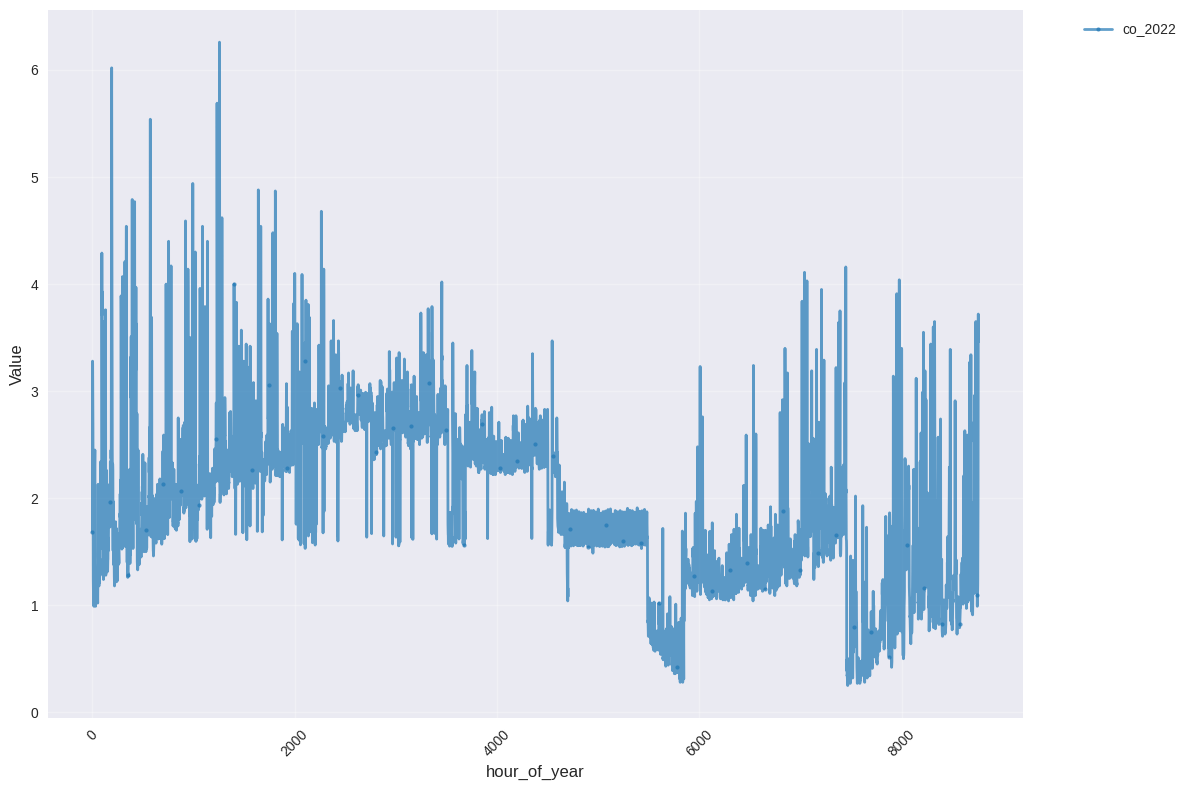

In [8]:
visualize_ts_dataframe(df_co_2022_imputed,"hour_of_year")

## Ornstein Uhlenbeck Process

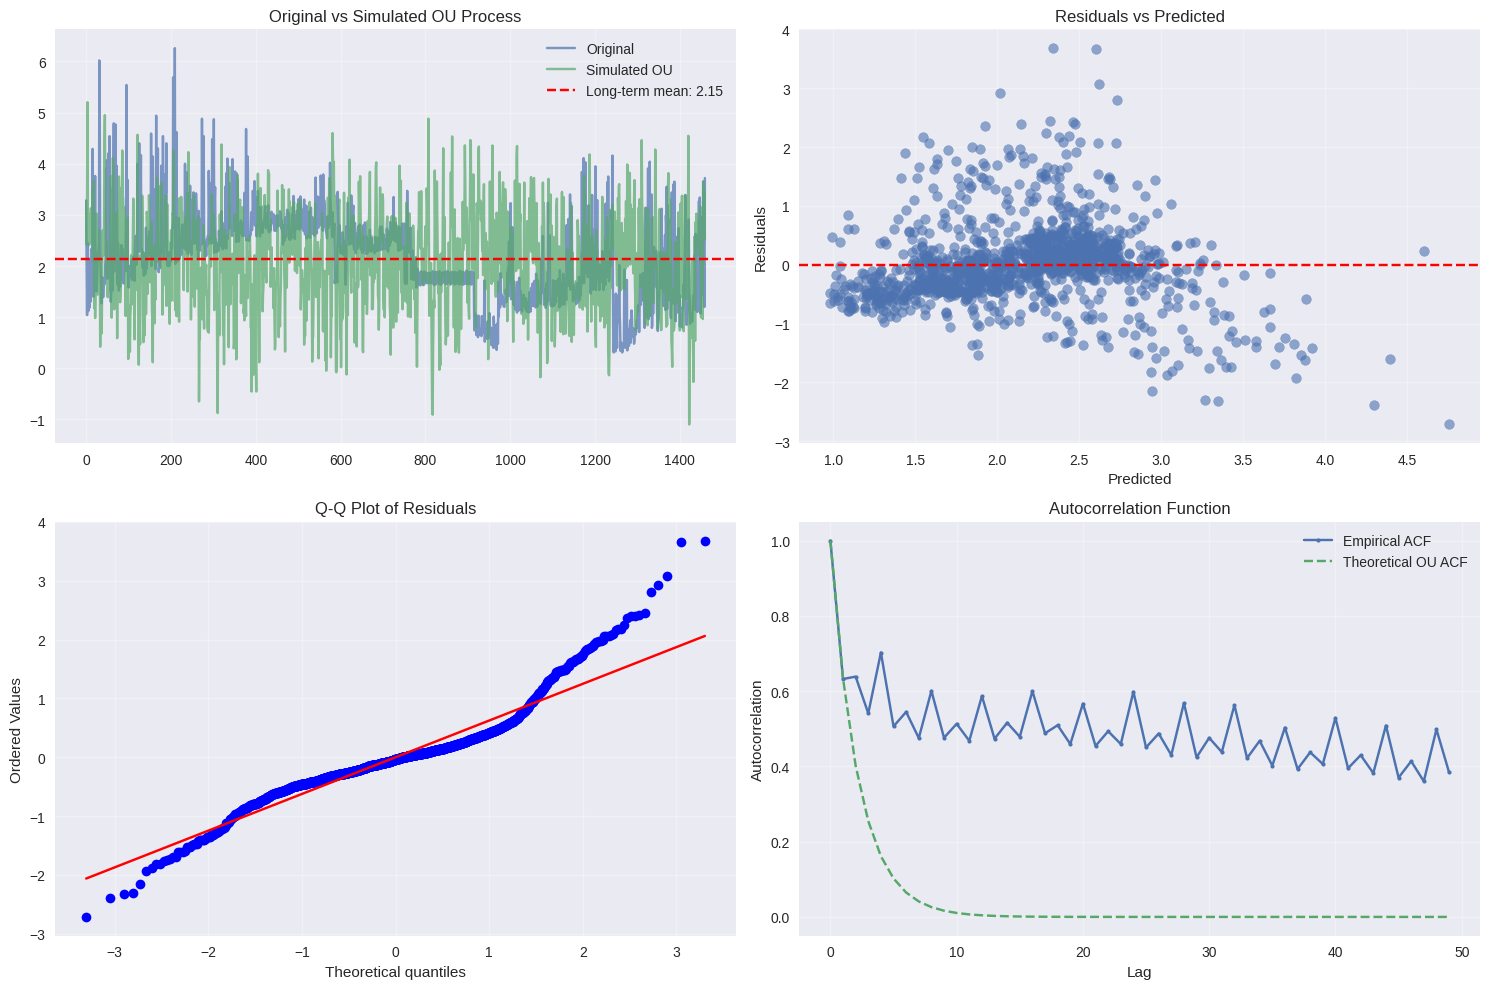

Estimated parameters:
θ = 0.4561
μ = 2.1467
σ = 0.8043
Half-life = 1.52 time units


In [9]:
from scipy import optimize
from scipy.stats import norm
from typing import Tuple, Optional
import warnings

class OrnsteinUhlenbeckModel:
    """
    Ornstein-Uhlenbeck process modeling and parameter estimation
    
    The OU process follows: dX_t = θ(μ - X_t)dt +  .σdW_t
    where:
    - θ (theta): mean reversion speed
    - μ (mu): long-term mean level
    - σ (sigma): volatility parameter
    """
    
    def __init__(self):
        self.theta: Optional[float] = None
        self.mu: Optional[float] = None
        self.sigma: Optional[float] = None
        self.fitted: bool = False
        
    def estimate_parameters_mle(self, data: np.ndarray, dt: float = 1.0) -> Tuple[float, float, float]:
        """
        Estimate OU parameters using Maximum Likelihood Estimation
        
        Args:
            data: Time series data as numpy array
            dt: Time step (default 1.0 for unit intervals)
            
        Returns:
            Tuple of (theta, mu, sigma)
        """
        data = np.array(data)
        n = len(data)
        
        if n < 3:
            raise ValueError("Need at least 3 data points for estimation")
        
        # Differences for MLE
        x = data[:-1]
        y = data[1:]
        
        # MLE estimation using discrete approximation
        def negative_log_likelihood(params):
            theta, mu, sigma = params
            
            # Avoid numerical issues
            if theta <= 0 or sigma <= 0:
                return np.inf
                
            # Expected value and variance for discrete OU
            exp_theta_dt = np.exp(-theta * dt)
            conditional_mean = mu + (x - mu) * exp_theta_dt
            conditional_var = (sigma**2 / (2 * theta)) * (1 - exp_theta_dt**2)
            
            if conditional_var <= 0:
                return np.inf
                
            # Log-likelihood
            residuals = y - conditional_mean
            log_likelihood = -0.5 * n * np.log(2 * np.pi * conditional_var) - \
                           0.5 * np.sum(residuals**2) / conditional_var
            
            return -log_likelihood
        
        # Initial parameter guesses
        sample_mean = np.mean(data)
        sample_var = np.var(data)
        initial_theta = 0.1
        initial_mu = sample_mean
        initial_sigma = np.sqrt(2 * initial_theta * sample_var)
        
        # Optimization bounds
        bounds = [(1e-6, 10), (data.min() - sample_var, data.max() + sample_var), (1e-6, 10)]
        
        try:
            result = optimize.minimize(
                negative_log_likelihood,
                x0=[initial_theta, initial_mu, initial_sigma],
                bounds=bounds,
                method='L-BFGS-B'
            )
            
            if result.success:
                self.theta, self.mu, self.sigma = result.x
                self.fitted = True
                return self.theta, self.mu, self.sigma # type: ignore
            else:
                raise RuntimeError("Optimization failed")
                
        except Exception as e:
            warnings.warn(f"MLE estimation failed: {e}. Using method of moments.")
            return self.estimate_parameters_moments(data, dt)
    
    def estimate_parameters_moments(self, data: np.ndarray, dt: float = 1.0) -> Tuple[float, float, float]:
        """
        Estimate OU parameters using method of moments
        
        Args:
            data: Time series data
            dt: Time step
            
        Returns:
            Tuple of (theta, mu, sigma)
        """
        data = np.array(data)
        
        # Sample statistics
        sample_mean = np.mean(data)
        sample_var = np.var(data)
        
        # Lag-1 autocorrelation
        if len(data) > 1:
            x = data[:-1]
            y = data[1:]
            autocorr = np.corrcoef(x, y)[0, 1]
        else:
            autocorr = 0.5
        
        # Method of moments estimators
        if autocorr > 0:
            self.theta = -np.log(max(autocorr, 1e-6)) / dt
        else:
            self.theta = 0.1  # Default fallback
            
        self.mu = sample_mean # type: ignore
        
        if self.theta > 0: # type: ignore
            self.sigma = np.sqrt(2 * self.theta * sample_var) # type: ignore
        else:
            self.sigma = np.sqrt(sample_var)
            
        self.fitted = True
        return self.theta, self.mu, self.sigma # type: ignore
    
    def fit(self, data: np.ndarray, dt: float = 1.0, method: str = 'mle') -> 'OrnsteinUhlenbeckModel':
        """
        Fit the OU model to data
        
        Args:
            data: Time series data
            dt: Time step
            method: 'mle' or 'moments'
            
        Returns:
            Self for chaining
        """
        if method == 'mle':
            self.estimate_parameters_mle(data, dt)
        elif method == 'moments':
            self.estimate_parameters_moments(data, dt)
        else:
            raise ValueError("Method must be 'mle' or 'moments'")
            
        return self
    
    def simulate(self, T: int, dt: float = 1.0, x0: Optional[float] = None) -> np.ndarray:
        """
        Simulate OU process
        
        Args:
            T: Number of time steps
            dt: Time step size
            x0: Initial value (if None, uses mu)
            
        Returns:
            Simulated path
        """
        if not self.fitted:
            raise ValueError("Model must be fitted before simulation")
            
        if x0 is None:
            x0 = self.mu
            
        # Euler-Maruyama scheme
        path = np.zeros(T)
        path[0] = x0
        
        sqrt_dt = np.sqrt(dt)
        
        for i in range(1, T):
            drift = self.theta * (self.mu - path[i-1]) * dt
            diffusion = self.sigma * sqrt_dt * np.random.normal()
            path[i] = path[i-1] + drift + diffusion
            
        return path
    
    def log_likelihood(self, data: np.ndarray, dt: float = 1.0) -> float:
        """
        Calculate log-likelihood of data given fitted parameters
        """
        if not self.fitted:
            raise ValueError("Model must be fitted first")
            
        data = np.array(data)
        n = len(data) - 1
        
        x = data[:-1]
        y = data[1:]
        
        exp_theta_dt = np.exp(-self.theta * dt) # type: ignore
        conditional_mean = self.mu + (x - self.mu) * exp_theta_dt
        conditional_var = (self.sigma**2 / (2 * self.theta)) * (1 - exp_theta_dt**2) # type: ignore
        
        residuals = y - conditional_mean
        log_likelihood = -0.5 * n * np.log(2 * np.pi * conditional_var) - \
                        0.5 * np.sum(residuals**2) / conditional_var
        
        return log_likelihood
    
    def aic(self, data: np.ndarray, dt: float = 1.0) -> float:
        """Calculate Akaike Information Criterion"""
        return 2 * 3 - 2 * self.log_likelihood(data, dt)  # 3 parameters
    
    def bic(self, data: np.ndarray, dt: float = 1.0) -> float:
        """Calculate Bayesian Information Criterion"""
        n = len(data) - 1
        return np.log(n) * 3 - 2 * self.log_likelihood(data, dt)
    
    def half_life(self) -> float:
        """Calculate mean reversion half-life"""
        if not self.fitted or self.theta <= 0: # type: ignore
            return np.inf
        return np.log(2) / self.theta
    
    def summary(self) -> dict:
        """Return summary of fitted parameters"""
        if not self.fitted:
            return {"fitted": False}
            
        return {
            "fitted": True,
            "theta": self.theta,
            "mu": self.mu, 
            "sigma": self.sigma,
            "half_life": self.half_life(),
            "mean_reversion_speed": self.theta,
            "long_term_mean": self.mu,
            "volatility": self.sigma
        }

def analyze_ou_process(data: pd.DataFrame, 
                      index_col: str, 
                      value_col: str,
                      dt: float = 1.0,
                      plot: bool = True) -> dict:
    """
    Complete analysis of time series as OU process
    
    Args:
        data: DataFrame with time series
        index_col: Name of index column
        value_col: Name of value column
        dt: Time step
        plot: Whether to create diagnostic plots
        
    Returns:
        Dictionary with analysis results
    """
    # Extract data
    series_data = data[value_col].dropna().values
    
    # Fit OU model
    ou_model = OrnsteinUhlenbeckModel()
    ou_model.fit(series_data, dt=dt, method='mle') # type: ignore
    
    # Generate statistics
    results = ou_model.summary()
    results['aic'] = ou_model.aic(series_data, dt) # type: ignore
    results['bic'] = ou_model.bic(series_data, dt) # type: ignore
    results['log_likelihood'] = ou_model.log_likelihood(series_data, dt) # type: ignore
    
    # Simulate for comparison
    simulated = ou_model.simulate(len(series_data), dt=dt, x0=series_data[0])
    
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Original vs simulated
        axes[0, 0].plot(series_data, label='Original', alpha=0.7)
        axes[0, 0].plot(simulated, label='Simulated OU', alpha=0.7)
        axes[0, 0].axhline(y=ou_model.mu, color='red', linestyle='--', label=f'Long-term mean: {ou_model.mu:.2f}')
        axes[0, 0].set_title('Original vs Simulated OU Process')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Residuals analysis
        x = series_data[:-1]
        y = series_data[1:]
        exp_theta_dt = np.exp(-ou_model.theta * dt) # type: ignore
        predicted = ou_model.mu + (x - ou_model.mu) * exp_theta_dt # type: ignore
        residuals = y - predicted
        
        axes[0, 1].scatter(predicted, residuals, alpha=0.6)
        axes[0, 1].axhline(y=0, color='red', linestyle='--')
        axes[0, 1].set_xlabel('Predicted')
        axes[0, 1].set_ylabel('Residuals')
        axes[0, 1].set_title('Residuals vs Predicted')
        axes[0, 1].grid(True, alpha=0.3)
        
        # QQ plot of residuals
        from scipy import stats
        stats.probplot(residuals, dist="norm", plot=axes[1, 0])
        axes[1, 0].set_title('Q-Q Plot of Residuals')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Autocorrelation function
        def autocorr(x, max_lag=50):
            n = len(x)
            x = x - np.mean(x)
            autocorrs = np.correlate(x, x, mode='full')
            autocorrs = autocorrs[n-1:]
            autocorrs = autocorrs / autocorrs[0]
            return autocorrs[:min(max_lag, len(autocorrs))]
        
        lags = range(min(50, len(series_data)//4))
        acf_values = autocorr(series_data, max_lag=len(lags))
        theoretical_acf = [np.exp(-ou_model.theta * lag * dt) for lag in lags] # type: ignore
        
        axes[1, 1].plot(lags, acf_values[:len(lags)], 'o-', label='Empirical ACF', markersize=3)
        axes[1, 1].plot(lags, theoretical_acf, '--', label='Theoretical OU ACF')
        axes[1, 1].set_xlabel('Lag')
        axes[1, 1].set_ylabel('Autocorrelation')
        axes[1, 1].set_title('Autocorrelation Function')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return results

# Example usage
if __name__ == "__main__":
    # Generate sample OU data for testing
    true_theta, true_mu, true_sigma = 0.5, 2.0, 0.3
    dt = 1.0
    
    results = analyze_ou_process(df_co_2022_smoothed, 'hour_of_year', 'co_2022_max_6h', dt=dt, plot=True)
    
    print(f"Estimated parameters:")
    print(f"θ = {results['theta']:.4f}")
    print(f"μ = {results['mu']:.4f}")  
    print(f"σ = {results['sigma']:.4f}")
    print(f"Half-life = {results['half_life']:.2f} time units")

In [10]:
from typing import Tuple, Optional, Dict, List

class SeasonalOUModel:
    """
    Seasonal Ornstein-Uhlenbeck model for climate data with constraints
    
    Modifications for climate data:
    1. Log-transform to ensure positivity
    2. Seasonal parameter estimation (4 seasons)
    3. Better initialization for climate variables
    """
    
    def __init__(self):
        self.seasonal_params: Dict[int, Dict[str, float]] = {}
        self.fitted: bool = False
        self.transform: str = 'log'  # log, sqrt, or none
        
    def _transform_data(self, data: np.ndarray, method: str = 'log') -> np.ndarray:
        """Transform data to ensure positivity and better behavior"""
        if method == 'log':
            # Add small constant to avoid log(0)
            return np.log(data + 1e-6)
        elif method == 'sqrt':
            return np.sqrt(np.maximum(data, 0))
        else:
            return data
    
    def _inverse_transform(self, data: np.ndarray, method: str = 'log') -> np.ndarray:
        """Inverse transform back to original scale"""
        if method == 'log':
            return np.exp(data)
        elif method == 'sqrt':
            return data ** 2
        else:
            return data
    
    def _split_by_seasons(self, data: np.ndarray, hours_per_season: int = 2190) -> Dict[int, np.ndarray]:
        """
        Split yearly data into 4 seasons
        
        Args:
            data: Annual time series data
            hours_per_season: Hours per season (8760/4 = 2190)
            
        Returns:
            Dictionary with season number as key and data as value
        """
        seasons = {}
        n_data = len(data)
        
        for season in range(4):
            start_idx = season * hours_per_season
            end_idx = min((season + 1) * hours_per_season, n_data)
            
            if start_idx < n_data:
                seasons[season] = data[start_idx:end_idx]
        
        return seasons
    
    def _estimate_ou_parameters_robust(self, data: np.ndarray, dt: float = 1.0) -> Tuple[float, float, float]:
        """
        Robust OU parameter estimation for climate data
        """
        if len(data) < 10:
            # Fallback for small samples
            return 0.1, np.mean(data), np.std(data) # type: ignore
        
        # Transform data
        transformed_data = self._transform_data(data, self.transform)
        
        def negative_log_likelihood(params):
            theta, mu, sigma = params
            
            if theta <= 0 or sigma <= 0:
                return np.inf
            
            x = transformed_data[:-1]
            y = transformed_data[1:]
            
            exp_theta_dt = np.exp(-theta * dt)
            conditional_mean = mu + (x - mu) * exp_theta_dt
            conditional_var = (sigma**2 / (2 * theta)) * (1 - exp_theta_dt**2)
            
            if conditional_var <= 0:
                return np.inf
            
            residuals = y - conditional_mean
            log_likelihood = -0.5 * len(x) * np.log(2 * np.pi * conditional_var) - \
                           0.5 * np.sum(residuals**2) / conditional_var
            
            return -log_likelihood
        
        # Better initial estimates for climate data
        sample_mean = np.mean(transformed_data)
        sample_var = np.var(transformed_data)
        sample_std = np.std(transformed_data)
        
        # Use lag-1 autocorrelation for theta initialization
        if len(transformed_data) > 1:
            autocorr = np.corrcoef(transformed_data[:-1], transformed_data[1:])[0, 1]
            initial_theta = max(-np.log(max(autocorr, 0.01)) / dt, 0.01)
        else:
            initial_theta = 0.1
        
        initial_mu = sample_mean
        initial_sigma = sample_std * np.sqrt(2 * initial_theta)
        
        # Expanded bounds for climate data
        bounds = [
            (0.001, 5.0),  # theta
            (sample_mean - 3 * sample_std, sample_mean + 3 * sample_std),  # mu
            (0.001, 5 * sample_std)  # sigma
        ]
        
        try:
            result = optimize.minimize(
                negative_log_likelihood,
                x0=[initial_theta, initial_mu, initial_sigma],
                bounds=bounds,
                method='L-BFGS-B'
            )
            
            if result.success:
                return result.x
            else:
                raise RuntimeError("Optimization failed")
                
        except Exception as e:
            warnings.warn(f"MLE failed: {e}. Using robust fallback.")
            # Robust fallback
            theta = initial_theta
            mu = sample_mean
            sigma = sample_std
            return theta, mu, sigma # type: ignore
    
    def fit_seasonal(self, data: np.ndarray, dt: float = 1.0, 
                    hours_per_season: int = 2190) -> 'SeasonalOUModel':
        """
        Fit seasonal OU model
        
        Args:
            data: Full year time series data
            dt: Time step
            hours_per_season: Hours per season (default 8760/4 = 2190)
        """
        # Split into seasons
        seasonal_data = self._split_by_seasons(data, hours_per_season)
        
        # Fit each season
        for season, season_data in seasonal_data.items():
            if len(season_data) > 5:  # Minimum data requirement
                theta, mu, sigma = self._estimate_ou_parameters_robust(season_data, dt)
                
                self.seasonal_params[season] = { # type: ignore
                    'theta': theta,
                    'mu': mu,
                    'sigma': sigma,
                    'n_points': len(season_data),
                    'original_mean': np.mean(season_data),
                    'original_std': np.std(season_data)
                }
        
        self.fitted = True
        return self
    
    def simulate_seasonal_ensemble(self, n_simulations: int = 1000, 
                                  hours_per_season: int = 2190, 
                                  dt: float = 1.0) -> Dict[str, np.ndarray]:
        """
        Generate ensemble of seasonal simulations
        
        Args:
            n_simulations: Number of trajectory simulations
            hours_per_season: Hours per season
            dt: Time step
            
        Returns:
            Dictionary with ensemble statistics
        """
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        total_hours = hours_per_season * 4
        ensemble = np.zeros((n_simulations, total_hours))
        
        for sim in range(n_simulations):
            full_simulation = []
            
            for season in range(4):
                if season in self.seasonal_params:
                    params = self.seasonal_params[season]
                    theta, mu, sigma = params['theta'], params['mu'], params['sigma']
                    
                    # Simulate season in transformed space
                    path = np.zeros(hours_per_season)
                    if len(full_simulation) > 0:
                        # Continue from previous season
                        path[0] = self._transform_data(np.array([full_simulation[-1]]), self.transform)[0]
                    else:
                        path[0] = mu + np.random.normal(0, sigma / np.sqrt(2 * theta))
                    
                    sqrt_dt = np.sqrt(dt)
                    for i in range(1, hours_per_season):
                        drift = theta * (mu - path[i-1]) * dt
                        diffusion = sigma * sqrt_dt * np.random.normal()
                        path[i] = path[i-1] + drift + diffusion
                    
                    # Transform back to original scale
                    season_sim = self._inverse_transform(path, self.transform)
                    full_simulation.extend(season_sim.tolist())
                else:
                    # If no parameters for season, use overall mean
                    overall_mean = np.mean([p['original_mean'] for p in self.seasonal_params.values()])
                    season_sim = np.full(hours_per_season, overall_mean)
                    full_simulation.extend(season_sim.tolist())
            
            ensemble[sim, :] = full_simulation[:total_hours]
        
        # Calculate ensemble statistics
        ensemble_stats = {
            'trajectories': ensemble,
            'mean': np.mean(ensemble, axis=0),
            'median': np.median(ensemble, axis=0),
            'std': np.std(ensemble, axis=0),
            'percentile_5': np.percentile(ensemble, 5, axis=0),
            'percentile_25': np.percentile(ensemble, 25, axis=0),
            'percentile_75': np.percentile(ensemble, 75, axis=0),
            'percentile_95': np.percentile(ensemble, 95, axis=0),
            'min': np.min(ensemble, axis=0),
            'max': np.max(ensemble, axis=0)
        }
        
        return ensemble_stats
    
    def predict_with_uncertainty(self, target_hours: np.ndarray, 
                                n_simulations: int = 1000,
                                hours_per_season: int = 2190) -> Dict[str, np.ndarray]:
        """
        Predict values at specific hours with uncertainty quantification
        
        Args:
            target_hours: Array of hour indices to predict
            n_simulations: Number of simulations for ensemble
            hours_per_season: Hours per season
            
        Returns:
            Dictionary with predictions and uncertainty bounds
        """
        ensemble_stats = self.simulate_seasonal_ensemble(n_simulations, hours_per_season)
        
        # Extract predictions for target hours
        target_indices = np.array(target_hours) - 1  # Convert to 0-based indexing
        valid_indices = target_indices[target_indices < len(ensemble_stats['mean'])]
        
        predictions = {
            'hours': target_hours[target_indices < len(ensemble_stats['mean'])],
            'mean_prediction': ensemble_stats['mean'][valid_indices],
            'median_prediction': ensemble_stats['median'][valid_indices],
            'std_prediction': ensemble_stats['std'][valid_indices],
            'lower_5': ensemble_stats['percentile_5'][valid_indices],
            'lower_25': ensemble_stats['percentile_25'][valid_indices],
            'upper_75': ensemble_stats['percentile_75'][valid_indices],
            'upper_95': ensemble_stats['percentile_95'][valid_indices],
            'prediction_interval_90': (ensemble_stats['percentile_5'][valid_indices], 
                                     ensemble_stats['percentile_95'][valid_indices]),
            'prediction_interval_50': (ensemble_stats['percentile_25'][valid_indices], 
                                     ensemble_stats['percentile_75'][valid_indices])
        }
        
        return predictions
    
    def simulate_seasonal(self, hours_per_season: int = 2190, 
                         dt: float = 1.0) -> np.ndarray:
        """
        Simulate full year with seasonal parameters
        """
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        full_simulation = []
        
        for season in range(4):
            if season in self.seasonal_params:
                params = self.seasonal_params[season]
                theta, mu, sigma = params['theta'], params['mu'], params['sigma']
                
                # Simulate season in transformed space
                path = np.zeros(hours_per_season)
                if len(full_simulation) > 0:
                    # Continue from previous season
                    path[0] = self._transform_data(np.array([full_simulation[-1]]), self.transform)[0]
                else:
                    path[0] = mu
                
                sqrt_dt = np.sqrt(dt)
                for i in range(1, hours_per_season):
                    drift = theta * (mu - path[i-1]) * dt
                    diffusion = sigma * sqrt_dt * np.random.normal()
                    path[i] = path[i-1] + drift + diffusion
                
                # Transform back to original scale
                season_sim = self._inverse_transform(path, self.transform)
                full_simulation.extend(season_sim.tolist())
            else:
                # If no parameters for season, use overall mean
                overall_mean = np.mean([p['original_mean'] for p in self.seasonal_params.values()])
                season_sim = np.full(hours_per_season, overall_mean)
                full_simulation.extend(season_sim.tolist())
        
        return np.array(full_simulation)
    
    def summary(self) -> Dict:
        """Return summary of seasonal parameters"""
        if not self.fitted:
            return {"fitted": False}
        
        summary = {"fitted": True, "transform": self.transform, "seasons": {}}
        
        for season, params in self.seasonal_params.items():
            season_names = ["Winter", "Spring", "Summer", "Fall"]
            summary["seasons"][season_names[season]] = {
                "theta": params['theta'],
                "mu": params['mu'],
                "sigma": params['sigma'],
                "original_mean": params['original_mean'],
                "original_std": params['original_std'],
                "half_life": np.log(2) / params['theta'] if params['theta'] > 0 else np.inf,
                "n_points": params['n_points']
            }
        
        return summary

def analyze_seasonal_ou(data: pd.DataFrame,
                       index_col: str,
                       value_col: str,
                       dt: float = 1.0,
                       hours_per_season: int = 2190,
                       n_simulations: int = 1000,
                       plot: bool = True) -> Dict:
    """
    Analyze time series using seasonal OU model with ensemble simulations
    
    Args:
        data: DataFrame with time series
        index_col: Name of index column
        value_col: Name of value column  
        dt: Time step
        hours_per_season: Hours per season
        n_simulations: Number of ensemble simulations
        plot: Whether to create plots
    """
    # Extract data
    series_data = data[value_col].dropna().values
    
    # Ensure positive values for climate data
    if np.any(series_data <= 0): # type: ignore
        print(f"Warning: Found {np.sum(series_data <= 0)} non-positive values. Adding offset.") # type: ignore # type: ignore # type: ignore
        series_data = series_data - np.min(series_data) + 0.1 # type: ignore
    
    # Fit seasonal model
    seasonal_model = SeasonalOUModel()
    seasonal_model.fit_seasonal(series_data, dt=dt, hours_per_season=hours_per_season) # type: ignore
    
    # Generate ensemble predictions
    print(f"Generating {n_simulations} ensemble simulations...")
    ensemble_stats = seasonal_model.simulate_seasonal_ensemble(
        n_simulations=n_simulations, 
        hours_per_season=hours_per_season, 
        dt=dt
    )
    
    # Get model summary
    results = seasonal_model.summary()
    
    # Add ensemble statistics to results
    results['ensemble'] = {
        'n_simulations': n_simulations,
        'mean_trajectory': ensemble_stats['mean'][:len(series_data)],
        'median_trajectory': ensemble_stats['median'][:len(series_data)],
        'uncertainty_bounds': {
            'lower_5': ensemble_stats['percentile_5'][:len(series_data)],
            'upper_95': ensemble_stats['percentile_95'][:len(series_data)],
            'lower_25': ensemble_stats['percentile_25'][:len(series_data)],
            'upper_75': ensemble_stats['percentile_75'][:len(series_data)]
        }
    }
    
    # Calculate model performance metrics
    ensemble_mean = ensemble_stats['mean'][:len(series_data)]
    ensemble_median = ensemble_stats['median'][:len(series_data)]
    
    results['performance'] = {
        'rmse_mean': np.sqrt(np.mean((series_data - ensemble_mean)**2)),
        'rmse_median': np.sqrt(np.mean((series_data - ensemble_median)**2)),
        'mae_mean': np.mean(np.abs(series_data - ensemble_mean)),
        'mae_median': np.mean(np.abs(series_data - ensemble_median)),
        'coverage_90': np.mean((series_data >= ensemble_stats['percentile_5'][:len(series_data)]) & 
                              (series_data <= ensemble_stats['percentile_95'][:len(series_data)])),
        'coverage_50': np.mean((series_data >= ensemble_stats['percentile_25'][:len(series_data)]) & 
                              (series_data <= ensemble_stats['percentile_75'][:len(series_data)]))
    }
    
    if plot:
        fig, axes = plt.subplots(3, 2, figsize=(18, 15))
        
        # Original vs ensemble mean/median with uncertainty bands
        time_idx = np.arange(len(series_data))
        
        axes[0, 0].fill_between(time_idx, 
                               ensemble_stats['percentile_5'][:len(series_data)],
                               ensemble_stats['percentile_95'][:len(series_data)],
                               alpha=0.2, color='blue', label='90% Prediction Interval')
        axes[0, 0].fill_between(time_idx,
                               ensemble_stats['percentile_25'][:len(series_data)],
                               ensemble_stats['percentile_75'][:len(series_data)],
                               alpha=0.3, color='blue', label='50% Prediction Interval')
        
        axes[0, 0].plot(series_data, label='Original', alpha=0.8, linewidth=1, color='black')
        axes[0, 0].plot(ensemble_mean, label=f'Ensemble Mean ({n_simulations} sims)', 
                       alpha=0.9, linewidth=2, color='red')
        axes[0, 0].plot(ensemble_median, label='Ensemble Median', 
                       alpha=0.9, linewidth=2, color='green', linestyle='--')
        
        # Add seasonal boundaries
        for i in range(1, 4):
            boundary = i * hours_per_season
            if boundary < len(series_data):
                axes[0, 0].axvline(x=boundary, color='orange', linestyle='--', alpha=0.7)
        
        axes[0, 0].set_title(f'Original vs Ensemble Seasonal OU ({n_simulations} trajectories)')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Sample of individual trajectories
        n_sample_trajectories = min(50, n_simulations)
        sample_indices = np.random.choice(n_simulations, n_sample_trajectories, replace=False)
        
        for i in sample_indices:
            axes[0, 1].plot(ensemble_stats['trajectories'][i, :len(series_data)], 
                           alpha=0.1, color='gray', linewidth=0.5)
        
        axes[0, 1].plot(series_data, label='Original', alpha=0.9, linewidth=2, color='black')
        axes[0, 1].plot(ensemble_mean, label='Ensemble Mean', alpha=0.9, linewidth=2, color='red')
        axes[0, 1].set_title(f'Sample of {n_sample_trajectories} Individual Trajectories')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Seasonal comparison with uncertainty
        season_names = ["Winter", "Spring", "Summer", "Fall"]
        original_means = []
        ensemble_means = []
        ensemble_stds = []
        
        for season in range(4):
            start_idx = season * hours_per_season
            end_idx = min((season + 1) * hours_per_season, len(series_data))
            
            if start_idx < len(series_data):
                original_means.append(np.mean(series_data[start_idx:end_idx])) # type: ignore
                ensemble_means.append(np.mean(ensemble_mean[start_idx:end_idx]))
                ensemble_stds.append(np.std(ensemble_mean[start_idx:end_idx]))
        
        x_pos = np.arange(len(season_names))
        width = 0.35
        
        axes[1, 0].bar(x_pos - width/2, original_means, width, label='Original', alpha=0.7)
        axes[1, 0].bar(x_pos + width/2, ensemble_means, width, 
                      yerr=ensemble_stds, label='Ensemble Mean ± Std', alpha=0.7, capsize=5)
        axes[1, 0].set_xlabel('Season')
        axes[1, 0].set_ylabel('Mean Value')
        axes[1, 0].set_title('Seasonal Means: Original vs Ensemble')
        axes[1, 0].set_xticks(x_pos)
        axes[1, 0].set_xticklabels(season_names)
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Residuals analysis
        residuals_mean = series_data - ensemble_mean
        residuals_median = series_data - ensemble_median
        
        axes[1, 1].scatter(ensemble_mean, residuals_mean, alpha=0.6, s=1, label='vs Ensemble Mean')
        axes[1, 1].scatter(ensemble_median, residuals_median, alpha=0.6, s=1, label='vs Ensemble Median')
        axes[1, 1].axhline(y=0, color='red', linestyle='--')
        axes[1, 1].set_xlabel('Predicted')
        axes[1, 1].set_ylabel('Residuals')
        axes[1, 1].set_title('Residuals Analysis')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        # Coverage analysis
        coverage_90 = ((series_data >= ensemble_stats['percentile_5'][:len(series_data)]) & 
                      (series_data <= ensemble_stats['percentile_95'][:len(series_data)]))
        coverage_50 = ((series_data >= ensemble_stats['percentile_25'][:len(series_data)]) & 
                      (series_data <= ensemble_stats['percentile_75'][:len(series_data)]))
        
        axes[2, 0].plot(coverage_90.astype(int), label=f'90% Coverage ({np.mean(coverage_90):.1%})', alpha=0.7)
        axes[2, 0].plot(coverage_50.astype(int), label=f'50% Coverage ({np.mean(coverage_50):.1%})', alpha=0.7)
        axes[2, 0].set_xlabel('Time Index')
        axes[2, 0].set_ylabel('Inside Prediction Interval')
        axes[2, 0].set_title('Prediction Interval Coverage')
        axes[2, 0].legend()
        axes[2, 0].grid(True, alpha=0.3)
        
        # Performance metrics visualization
        metrics_names = ['RMSE\n(Mean)', 'RMSE\n(Median)', 'MAE\n(Mean)', 'MAE\n(Median)']
        metrics_values = [results['performance']['rmse_mean'], 
                         results['performance']['rmse_median'],
                         results['performance']['mae_mean'],
                         results['performance']['mae_median']]
        
        bars = axes[2, 1].bar(metrics_names, metrics_values, alpha=0.7, 
                             color=['skyblue', 'lightgreen', 'salmon', 'gold'])
        axes[2, 1].set_ylabel('Error Value')
        axes[2, 1].set_title('Model Performance Metrics')
        axes[2, 1].grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, metrics_values):
            axes[2, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                           f'{value:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        # Print performance summary
        print(f"\nModel Performance Summary:")
        print(f"RMSE (Ensemble Mean): {results['performance']['rmse_mean']:.4f}")
        print(f"RMSE (Ensemble Median): {results['performance']['rmse_median']:.4f}")
        print(f"90% Prediction Interval Coverage: {results['performance']['coverage_90']:.1%}")
        print(f"50% Prediction Interval Coverage: {results['performance']['coverage_50']:.1%}")
    
    return results

Testing Seasonal OU Model:
Generating 100 ensemble simulations...


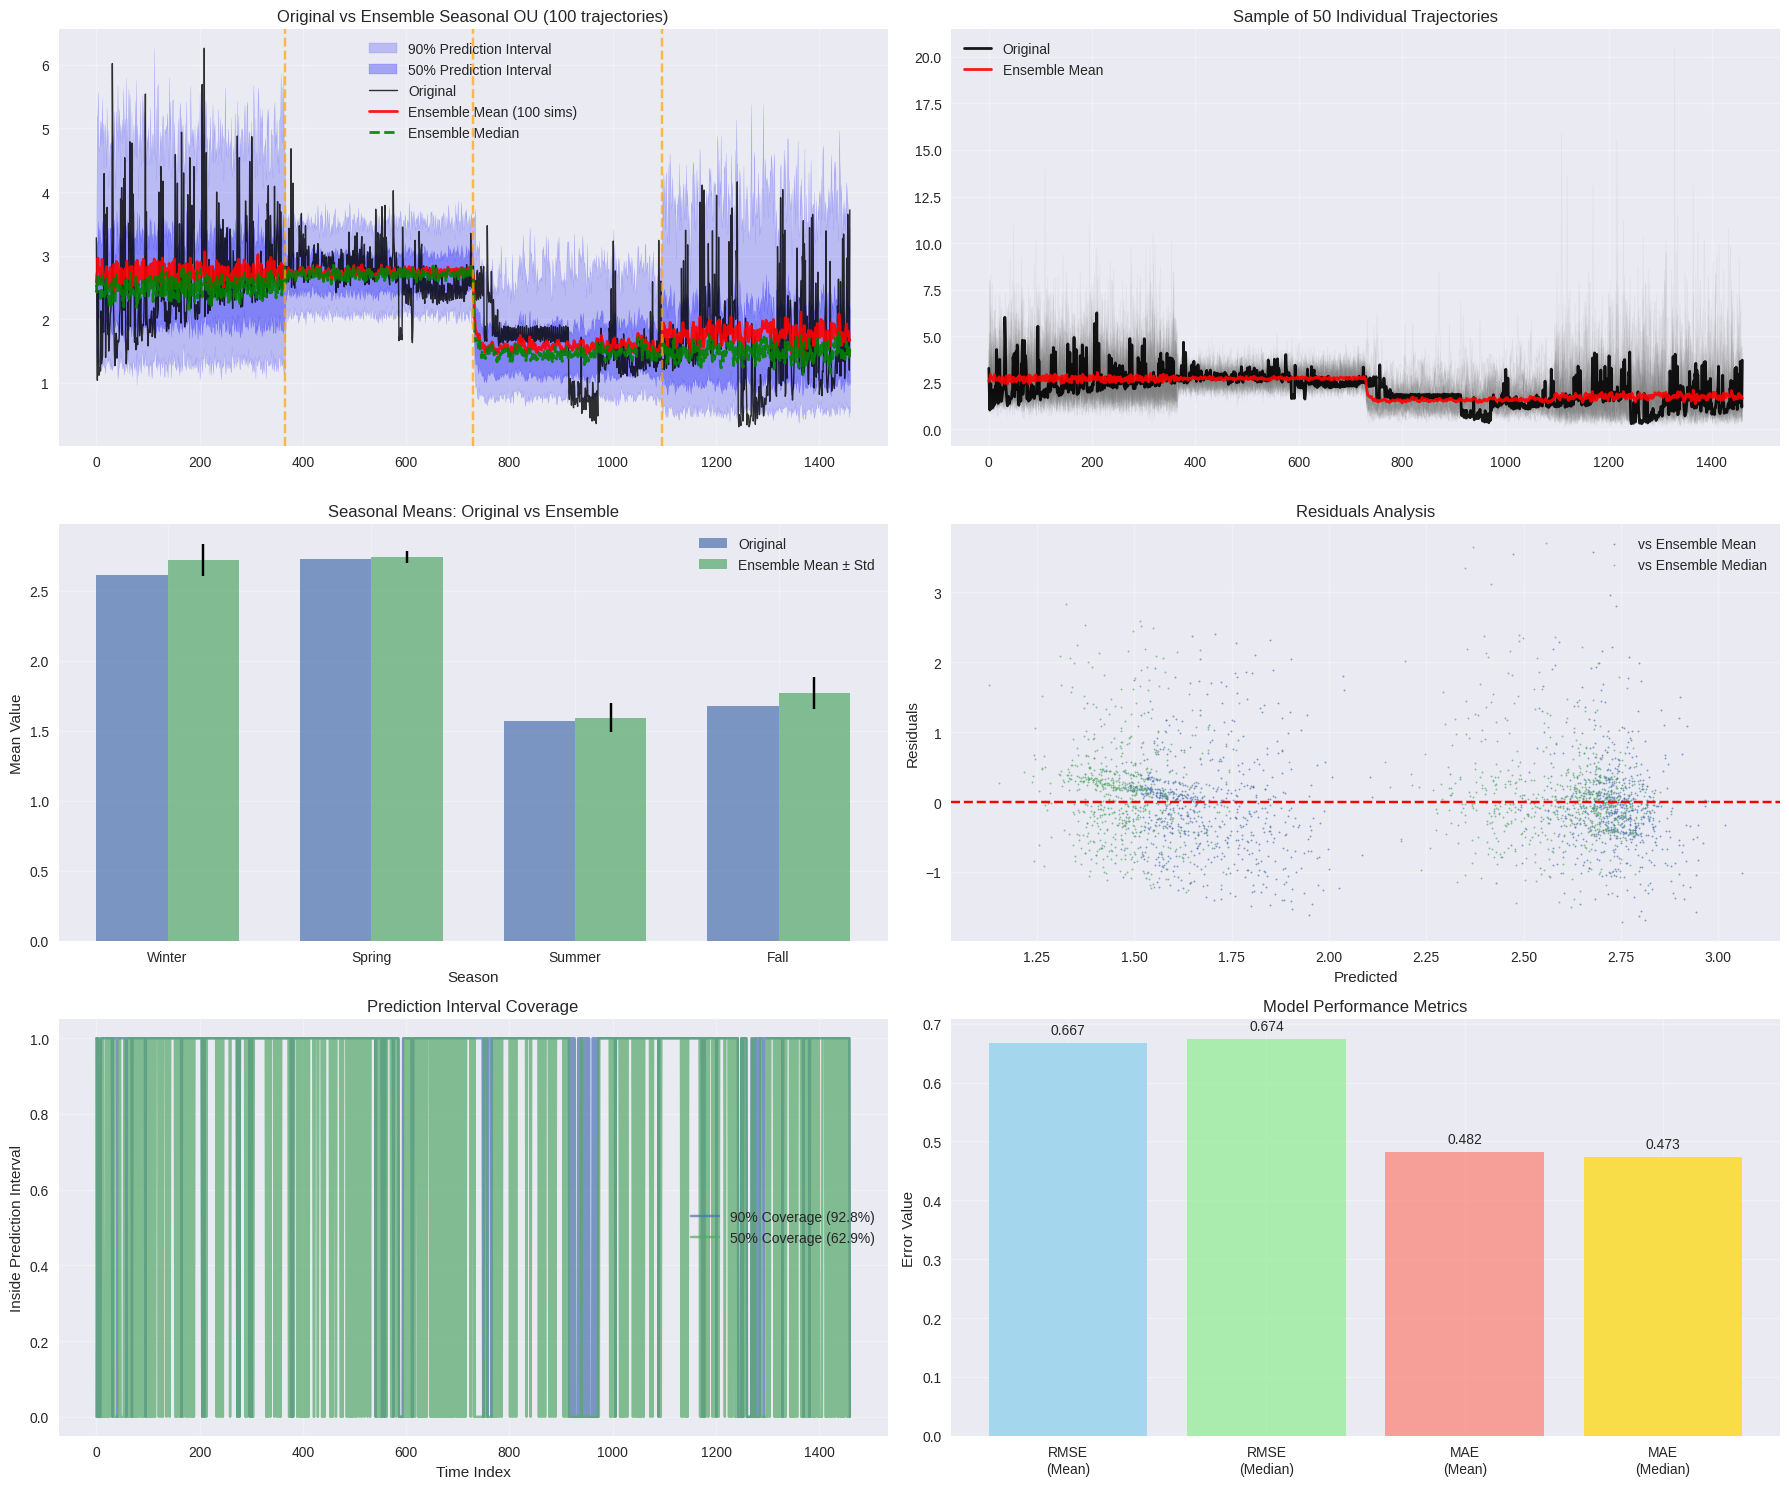


Model Performance Summary:
RMSE (Ensemble Mean): 0.6668
RMSE (Ensemble Median): 0.6739
90% Prediction Interval Coverage: 92.8%
50% Prediction Interval Coverage: 62.9%
RMSE: 0.6668
90% Coverage: 92.8%


In [11]:
print("Testing Seasonal OU Model:")
results = analyze_seasonal_ou(df_co_2022_smoothed, 'hour_index', 'co_2022_max_6h', 
                              n_simulations=100,
                              hours_per_season=365, plot=True)

# Access ensemble predictions
ensemble_mean = results['ensemble']['mean_trajectory']
confidence_bounds = results['ensemble']['uncertainty_bounds']


# Check model performance
print(f"RMSE: {results['performance']['rmse_mean']:.4f}")
print(f"90% Coverage: {results['performance']['coverage_90']:.1%}")

In [ ]:
import matplotlib.pyplot as plt
from typing import Dict, Tuple
from scipy import stats

def evaluate_seasonal_ou_simple(model, data: np.ndarray, 
                               hours_per_season: int = 365,
                               n_simulations: int = 1000,
                               test_split: float = 0.2) -> Dict:
    """
    Evaluación simple y directa del modelo OU estacional
    
    Args:
        model: Instancia de SeasonalOUModel ya entrenada
        data: Serie temporal original
        hours_per_season: Horas por estación
        n_simulations: Número de simulaciones para ensemble
        test_split: Fracción para test (últimos datos)
    """
    
    # Split simple: últimos datos para test
    split_point = int(len(data) * (1 - test_split))
    train_data = data[:split_point]
    test_data = data[split_point:]
    
    print(f"Evaluando modelo con {len(train_data)} datos de entrenamiento")
    print(f"Test en últimos {len(test_data)} puntos")
    print(f"Rango datos entrenamiento: [{np.min(train_data):.3f}, {np.max(train_data):.3f}]")
    print(f"Rango datos test: [{np.min(test_data):.3f}, {np.max(test_data):.3f}]")
    
    # Entrenar modelo
    model.fit_seasonal(train_data, hours_per_season=hours_per_season)
    
    # Diagnóstico del entrenamiento
    print("\nParámetros del modelo por estación:")
    if hasattr(model, 'seasonal_params'):
        for season, params in model.seasonal_params.items():
            season_names = ["Invierno", "Primavera", "Verano", "Otoño"]
            print(f"  {season_names[season]}: θ={params['theta']:.4f}, μ={params['mu']:.4f}, σ={params['sigma']:.4f}")
            print(f"    Media original: {params['original_mean']:.4f}, N puntos: {params['n_points']}")
    
    # Generar ensemble de simulaciones del tamaño correcto
    simulation_length = len(test_data)
    
    # Verificar que el modelo puede simular
    if hasattr(model, 'simulate_seasonal_ensemble'):
        print(f"\nGenerando {n_simulations} simulaciones de {simulation_length} puntos...")
        
        try:
            ensemble_stats = model.simulate_seasonal_ensemble(
                n_simulations=n_simulations,
                hours_per_season=simulation_length  # Usar el tamaño exacto del test
            )
            
            # Asegurar que tomamos exactamente el tamaño del test
            pred_mean = ensemble_stats['mean'][:simulation_length]
            pred_median = ensemble_stats['median'][:simulation_length]
            pred_std = ensemble_stats['std'][:simulation_length]
            pred_lower = ensemble_stats['percentile_5'][:simulation_length]
            pred_upper = ensemble_stats['percentile_95'][:simulation_length]
            
            print(f"Predicciones generadas: {len(pred_mean)} puntos")
            print(f"Rango predicciones: [{np.min(pred_mean):.3f}, {np.max(pred_mean):.3f}]")
            
        except Exception as e:
            print(f"Error en simulación ensemble: {e}")
            # Fallback: usar simulación simple
            single_sim = model.simulate_seasonal(hours_per_season=simulation_length)[:simulation_length]
            pred_mean = single_sim
            pred_median = single_sim
            pred_std = np.std(single_sim) * np.ones_like(single_sim)
            pred_lower = pred_mean - 1.96 * pred_std
            pred_upper = pred_mean + 1.96 * pred_std
            
    else:
        print("Modelo no tiene simulate_seasonal_ensemble, usando simulación simple")
        single_sim = model.simulate_seasonal(hours_per_season=simulation_length)[:simulation_length]
        pred_mean = single_sim
        pred_median = single_sim
        pred_std = np.std(single_sim) * np.ones_like(single_sim)
        pred_lower = pred_mean - 1.96 * pred_std
        pred_upper = pred_mean + 1.96 * pred_std
    
    # Verificar dimensiones
    assert len(pred_mean) == len(test_data), f"Dimensiones no coinciden: pred={len(pred_mean)}, test={len(test_data)}"
    
    # Métricas básicas
    rmse_mean = np.sqrt(np.mean((test_data - pred_mean)**2))
    rmse_median = np.sqrt(np.mean((test_data - pred_median)**2))
    mae_mean = np.mean(np.abs(test_data - pred_mean))
    mae_median = np.mean(np.abs(test_data - pred_median))
    
    # Métricas de incertidumbre
    coverage_90 = np.mean((test_data >= pred_lower) & (test_data <= pred_upper))
    mean_interval_width = np.mean(pred_upper - pred_lower)
    
    # Precisión direccional
    if len(test_data) > 1:
        actual_direction = np.diff(test_data) > 0
        pred_direction = np.diff(pred_mean) > 0
        directional_accuracy = np.mean(actual_direction == pred_direction)
    else:
        directional_accuracy = 0.5
    
    # Análisis de residuos
    residuals_mean = test_data - pred_mean
    residuals_median = test_data - pred_median
    
    # Normalidad de residuos (Shapiro-Wilk)
    if len(residuals_mean) >= 3:
        try:
            shapiro_stat, shapiro_pval = stats.shapiro(residuals_mean)
        except:
            shapiro_stat, shapiro_pval = np.nan, np.nan
    else:
        shapiro_stat, shapiro_pval = np.nan, np.nan
    
    # Autocorrelación de residuos
    if len(residuals_mean) > 1:
        try:
            autocorr_lag1 = np.corrcoef(residuals_mean[:-1], residuals_mean[1:])[0, 1]
        except:
            autocorr_lag1 = 0
    else:
        autocorr_lag1 = 0
    
    # Análisis ensemble - variabilidad entre simulaciones (si disponible)
    rmse_distribution = []
    if hasattr(model, 'simulate_seasonal_ensemble') and 'trajectories' in ensemble_stats: # type: ignore
        ensemble_trajectories = ensemble_stats['trajectories'][:, :simulation_length] # type: ignore
        
        # Calcular RMSE para cada simulación
        for sim in range(min(100, n_simulations)):
            if sim < ensemble_trajectories.shape[0]:
                sim_pred = ensemble_trajectories[sim, :]
                sim_rmse = np.sqrt(np.mean((test_data - sim_pred)**2))
                rmse_distribution.append(sim_rmse)
    
    # Estadísticas distribucionales del RMSE
    if rmse_distribution:
        rmse_mean_dist = np.mean(rmse_distribution)
        rmse_std_dist = np.std(rmse_distribution)
        rmse_cv = rmse_std_dist / rmse_mean_dist if rmse_mean_dist > 0 else np.inf
    else:
        rmse_mean_dist = rmse_mean
        rmse_std_dist = 0
        rmse_cv = 0
        rmse_distribution = [rmse_mean]
    
    # Diagnóstico adicional
    print(f"\nDiagnóstico de predicciones:")
    print(f"  Varianza datos test: {np.var(test_data):.4f}")
    print(f"  Varianza predicciones: {np.var(pred_mean):.4f}")
    print(f"  Ratio varianzas: {np.var(pred_mean)/np.var(test_data):.4f}")
    
    # Resultados
    results = {
        # Métricas básicas
        'rmse_mean': rmse_mean,
        'rmse_median': rmse_median,
        'mae_mean': mae_mean,
        'mae_median': mae_median,
        'directional_accuracy': directional_accuracy,
        
        # Métricas de incertidumbre
        'coverage_90': coverage_90,
        'mean_interval_width': mean_interval_width,
        'prediction_efficiency': coverage_90 / (mean_interval_width / np.std(test_data)) if np.std(test_data) > 0 else 0,
        
        # Análisis de residuos
        'residuals_mean_abs': np.mean(np.abs(residuals_mean)),
        'residuals_std': np.std(residuals_mean),
        'shapiro_pvalue': shapiro_pval,
        'autocorr_lag1': autocorr_lag1,
        
        # Análisis distribucional ensemble
        'rmse_distribution_mean': rmse_mean_dist,
        'rmse_distribution_std': rmse_std_dist,
        'rmse_coefficient_variation': rmse_cv,
        'rmse_distribution': rmse_distribution,
        
        # Datos para plotting
        'test_data': test_data,
        'train_data': train_data,
        'pred_mean': pred_mean,
        'pred_median': pred_median,
        'pred_std': pred_std,
        'pred_lower': pred_lower,
        'pred_upper': pred_upper,
        'residuals': residuals_mean,
        
        # Parámetros del modelo
        'model_summary': model.summary() if hasattr(model, 'summary') else {},
        'n_simulations': n_simulations,
        'test_size': len(test_data),
        'train_size': len(train_data)
    }
    
    return results

def plot_ou_evaluation(results: Dict) -> None:
    """
    Visualizar resultados de evaluación
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    test_data = results['test_data']
    pred_mean = results['pred_mean']
    pred_lower = results['pred_lower']
    pred_upper = results['pred_upper']
    residuals = results['residuals']
    rmse_dist = results['rmse_distribution']
    
    time_idx = np.arange(len(test_data))
    
    # 1. Predicciones vs Real con intervalos
    axes[0, 0].fill_between(time_idx, pred_lower, pred_upper, 
                           alpha=0.3, color='blue', label='90% Interval')
    axes[0, 0].plot(time_idx, test_data, 'o-', color='black', 
                   markersize=4, label='Observado', alpha=0.8)
    axes[0, 0].plot(time_idx, pred_mean, '--', color='red', 
                   linewidth=2, label='Predicción')
    axes[0, 0].set_title(f'Predicciones vs Real\nRMSE: {results["rmse_mean"]:.4f}')
    axes[0, 0].set_xlabel('Tiempo')
    axes[0, 0].set_ylabel('Valor')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Residuos vs tiempo
    axes[0, 1].scatter(time_idx, residuals, alpha=0.6, s=30)
    axes[0, 1].axhline(y=0, color='red', linestyle='--')
    axes[0, 1].set_title(f'Residuos vs Tiempo\nAutocorr lag-1: {results["autocorr_lag1"]:.3f}')
    axes[0, 1].set_xlabel('Tiempo')
    axes[0, 1].set_ylabel('Residuos')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Q-Q plot de residuos
    stats.probplot(residuals, dist="norm", plot=axes[0, 2])
    axes[0, 2].set_title(f'Q-Q Plot Residuos\nShapiro p-val: {results["shapiro_pvalue"]:.4f}')
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Distribución RMSE del ensemble
    axes[1, 0].hist(rmse_dist, bins=20, alpha=0.7, density=True, 
                   color='skyblue', edgecolor='black')
    axes[1, 0].axvline(results['rmse_distribution_mean'], color='red', 
                      linestyle='--', linewidth=2, label='Media')
    axes[1, 0].set_title(f'Distribución RMSE Ensemble\nCV: {results["rmse_coefficient_variation"]:.4f}')
    axes[1, 0].set_xlabel('RMSE')
    axes[1, 0].set_ylabel('Densidad')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Cobertura de intervalos
    coverage_series = (test_data >= pred_lower) & (test_data <= pred_upper)
    axes[1, 1].plot(time_idx, coverage_series.astype(int), 'o-', markersize=4)
    axes[1, 1].axhline(y=results['coverage_90'], color='red', linestyle='--', 
                      label=f'Cobertura: {results["coverage_90"]:.1%}')
    axes[1, 1].set_title('Cobertura Intervalos 90%')
    axes[1, 1].set_xlabel('Tiempo')
    axes[1, 1].set_ylabel('Dentro del Intervalo')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Métricas resumen
    axes[1, 2].axis('off')
    metrics_text = f"""
    MÉTRICAS PRINCIPALES:
    
    RMSE: {results['rmse_mean']:.4f}
    MAE: {results['mae_mean']:.4f}
    
    Precisión Direccional: {results['directional_accuracy']:.1%}
    Cobertura 90%: {results['coverage_90']:.1%}
    
    Ancho Intervalo Medio: {results['mean_interval_width']:.4f}
    
    Autocorr Residuos: {results['autocorr_lag1']:.3f}
    CV RMSE Ensemble: {results['rmse_coefficient_variation']:.4f}
    
    Simulaciones: {results['n_simulations']}
    Puntos Test: {results['test_size']}
    """
    axes[1, 2].text(0.1, 0.9, metrics_text, transform=axes[1, 2].transAxes,
                    fontsize=11, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def print_evaluation_summary(results: Dict) -> None:
    """
    Imprimir resumen de evaluación
    """
    print("="*60)
    print("EVALUACIÓN MODELO OU ESTACIONAL")
    print("="*60)
    
    print(f"\nMÉTRICAS DE PRECISIÓN:")
    print(f"  RMSE (Media): {results['rmse_mean']:.4f}")
    print(f"  RMSE (Mediana): {results['rmse_median']:.4f}")
    print(f"  MAE (Media): {results['mae_mean']:.4f}")
    print(f"  MAE (Mediana): {results['mae_median']:.4f}")
    print(f"  Precisión Direccional: {results['directional_accuracy']:.1%}")
    
    print(f"\nMÉTRICAS DE INCERTIDUMBRE:")
    print(f"  Cobertura 90%: {results['coverage_90']:.1%}")
    print(f"  Ancho Intervalo Medio: {results['mean_interval_width']:.4f}")
    print(f"  Eficiencia Predicción: {results['prediction_efficiency']:.4f}")
    
    print(f"\nANÁLISIS DE RESIDUOS:")
    print(f"  Std Residuos: {results['residuals_std']:.4f}")
    print(f"  Autocorr Lag-1: {results['autocorr_lag1']:.3f}")
    print(f"  Shapiro p-valor: {results['shapiro_pvalue']:.4f}")
    
    print(f"\nANÁLISIS DISTRIBUCIONAL ENSEMBLE:")
    print(f"  RMSE Medio: {results['rmse_distribution_mean']:.4f}")
    print(f"  RMSE Std: {results['rmse_distribution_std']:.4f}")
    print(f"  Coef. Variación: {results['rmse_coefficient_variation']:.4f}")
    
    # Interpretaciones
    print(f"\nINTERPRETACIONES:")
    
    if results['coverage_90'] > 0.85:
        print("  ✓ Intervalos bien calibrados")
    else:
        print("  ✗ Intervalos mal calibrados")
    
    if abs(results['autocorr_lag1']) < 0.1:
        print("  ✓ Residuos sin autocorrelación significativa")
    else:
        print("  ✗ Residuos con autocorrelación")
    
    if results['rmse_coefficient_variation'] < 0.2:
        print("  ✓ Modelo estable (baja variabilidad RMSE)")
    else:
        print("  ✗ Modelo inestable (alta variabilidad RMSE)")
    
    if results['directional_accuracy'] > 0.6:
        print("  ✓ Buena predicción de dirección")
    else:
        print("  ✗ Mala predicción de dirección")

# Función de uso simple
def evaluate_ou_model(data: np.ndarray, hours_per_season: int = 365) -> Dict:
    """
    Evaluación completa simple del modelo OU
    """  
    # Crear y evaluar modelo
    model = SeasonalOUModel()
    
    results = evaluate_seasonal_ou_simple(
        model=model,
        data=data,
        hours_per_season=hours_per_season,
        n_simulations=1000,
        test_split=0.2
    )
    
    # Mostrar resultados
    print_evaluation_summary(results)
    plot_ou_evaluation(results)
    
    return results

Evaluando modelo con 1168 datos de entrenamiento
Test en últimos 292 puntos
Rango datos entrenamiento: [0.360, 6.260]
Rango datos test: [0.310, 4.160]

Parámetros del modelo por estación:
  Invierno: θ=0.9614, μ=0.9149, σ=0.4092
    Media original: 2.6135, N puntos: 365
  Primavera: θ=0.6234, μ=0.9941, σ=0.1529
    Media original: 2.7283, N puntos: 365
  Verano: θ=0.2439, μ=0.3805, σ=0.2597
    Media original: 1.5710, N puntos: 365
  Otoño: θ=1.6435, μ=0.4623, σ=0.3899
    Media original: 1.6229, N puntos: 73

Generando 1000 simulaciones de 292 puntos...
Predicciones generadas: 292 puntos
Rango predicciones: [2.614, 2.826]

Diagnóstico de predicciones:
  Varianza datos test: 0.7593
  Varianza predicciones: 0.0014
  Ratio varianzas: 0.0018
EVALUACIÓN MODELO OU ESTACIONAL

MÉTRICAS DE PRECISIÓN:
  RMSE (Media): 1.3477
  RMSE (Mediana): 1.1897
  MAE (Media): 1.2000
  MAE (Mediana): 1.0432
  Precisión Direccional: 50.9%

MÉTRICAS DE INCERTIDUMBRE:
  Cobertura 90%: 63.4%
  Ancho Intervalo M

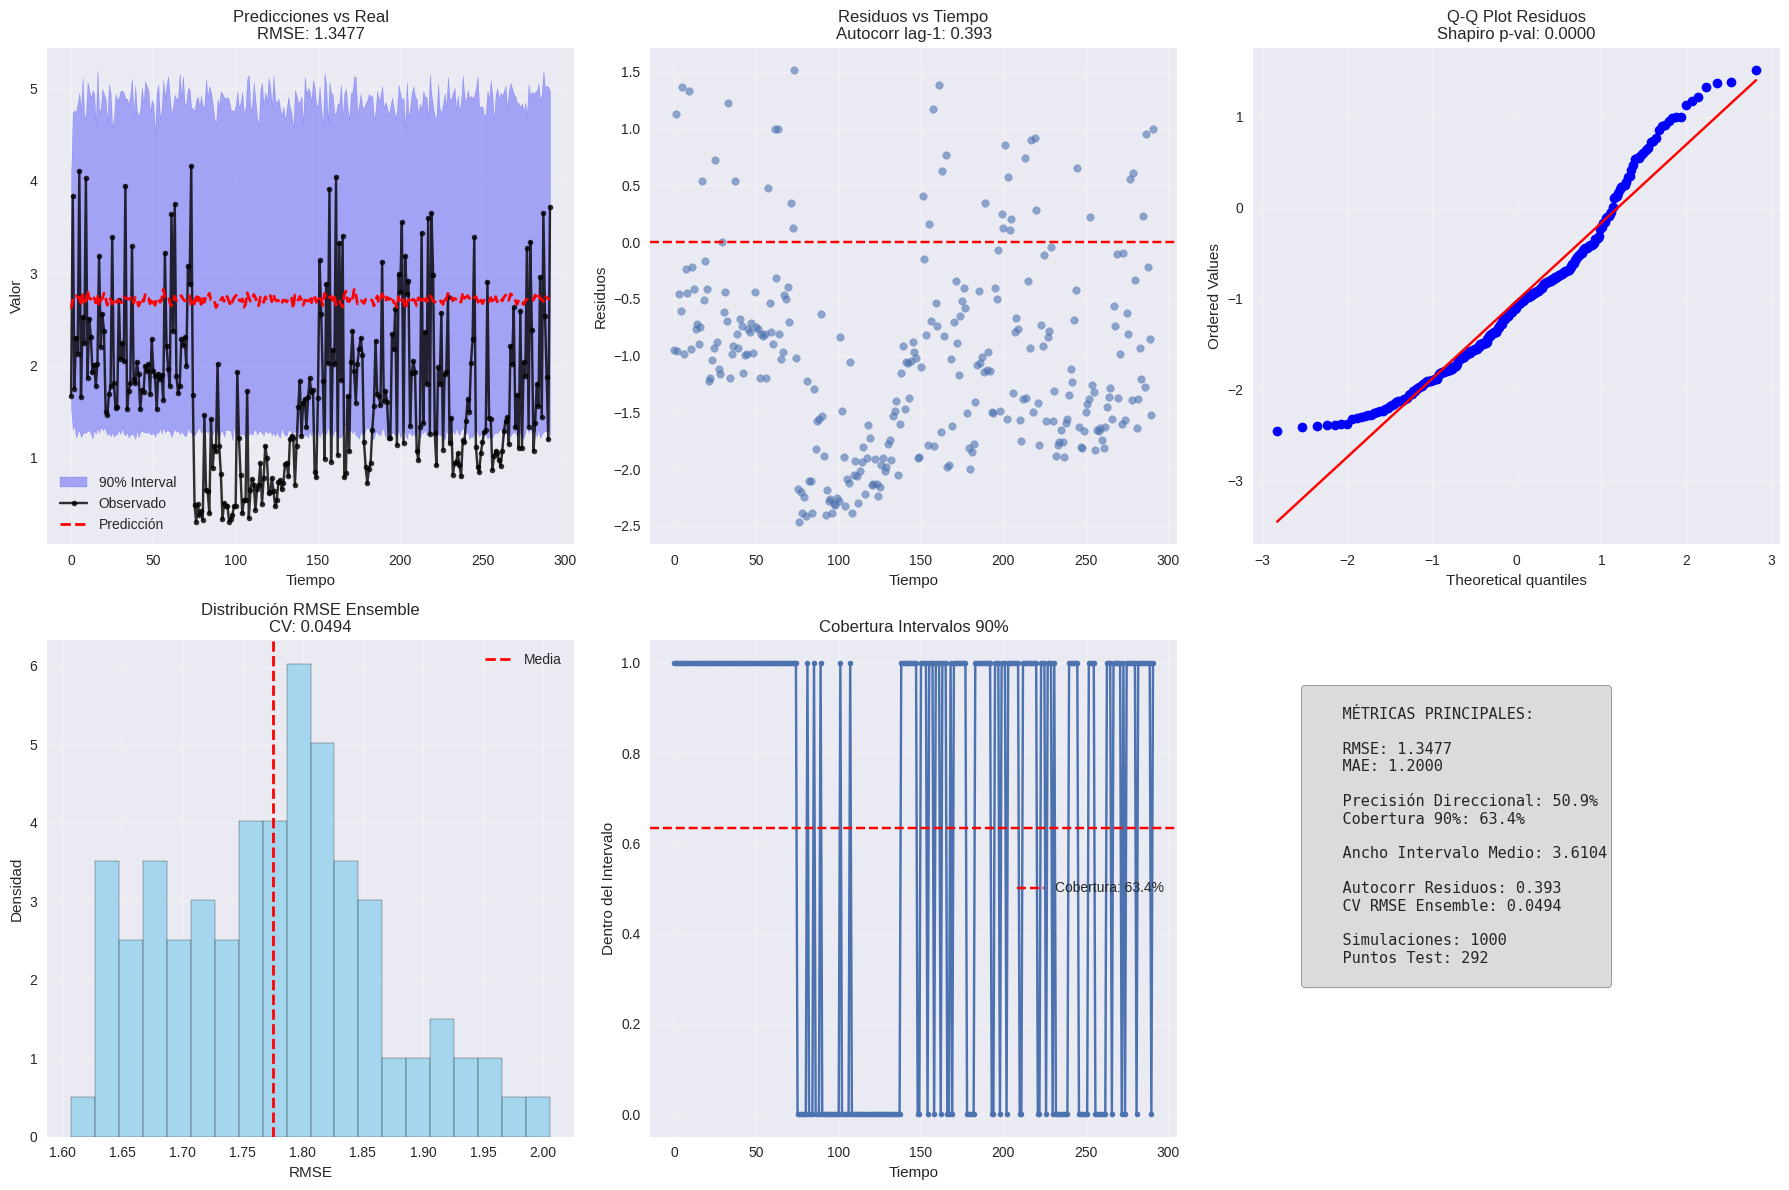

In [36]:
# Datos de ejemplo (usa tus datos reales)
co_values = df_co_2022_smoothed['co_2022_max_6h'].dropna().values

# Evaluación completa simple
results = evaluate_ou_model(
    data=co_values, # type: ignore
    hours_per_season=365  # Ajusta según tus datos
)